In [2]:
from langchain_openai import ChatOpenAI
from typing import TypedDict
from pydantic import BaseModel, Field
llm=ChatOpenAI(model="gpt-5-nano")
from langgraph.graph import StateGraph, START,END


class req_schema(BaseModel):
    topic:str=Field("name of the topic")
    post: str=Field("Linkedin post")
    curated_post:str=Field("Curated Linkedin Post")

def post(dict1:req_schema)->req_schema:
    dict1=dict1.model_dump()
    topic=dict1['topic']
    post=dict1['post']
    curated_post=dict1['curated_post']

    response=llm.invoke(f"please create a linkedin post on topic {topic}").content
    dict1['post']=f"the topic is : {topic}\nthe entire post is '{response}'"
    return dict1



def curate_post(dict1:req_schema)->req_schema:
    dict1=dict1.model_dump()
    topic=dict1['topic']
    post=dict1['post']
    curated_post=dict1['curated_post']

    response=llm.invoke(f"""using the below post , please create 5 questions with 
                        4 choice answers .\nAt the very end mention answers .\nThe post is : '{post}'""").content
    dict1['curated_post']=f"final curated linkedin post is \n'{response}'"
    return dict1



graph=StateGraph(req_schema)
graph.add_node("post", post)
graph.add_node("curate_post",curate_post)
graph.add_edge(START, "post")
graph.add_edge("post","curate_post")
graph.add_edge("curate_post",END)

first_graph=graph.compile()

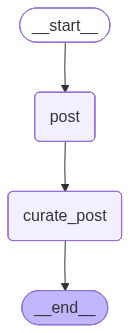

In [15]:
first_graph

In [ ]:
dict2={"topic":"python lists",
       "post":"ok ",
       "curate_post":" ok"}

# dict2=req_schema(
#     topic="python lists",
#     post="",
#     curated_post=""
# )

print(type(dict2))

first_graph.invoke(dict2)


<class 'dict'>


{'topic': 'python lists',
 'post': "the topic is : python lists\nthe entire post is 'Here's a ready-to-paste LinkedIn post about Python lists:\n\nPython lists: the Swiss Army knife of Python\n\nFrom handling small datasets to building dynamic pipelines, lists are at the heart of most Python work. Here are quick tips to level up your day-to-day with lists:\n\n- Core ops you’ll use a lot: creation, indexing, slicing, and mutating with append, extend, insert, remove, and pop.\n- Copying beware: remember that lists are mutable. A simple assignment copies the reference (aliasing). Use list.copy(), list slicing (lst[:]), or copy.deepcopy for nested lists.\n- Transform with style: prefer list comprehensions for clean, efficient transformations.\n- A few practical notes: avoid mutating a list while iterating; for performance, accumulate results with a list comprehension or .append() instead of repeated concatenation.\n\nMicro examples:\n- Basic mutation and filtering\n  numbers = [1, 2, 3, 4]\